# Training a custom scAdam model

**scAdam** is a multi-level automatic cell type annotation model implemented in the **scParadise** package. It assigns biologically interpretable cell-type labels to single-cell RNA-seq data and supports annotation across multiple levels of cellular hierarchy, from broad cell classes to more specific cell populations.

This tutorial demonstrates how to train a custom scAdam model using a user-defined reference dataset and cell-type hierarchy. You will learn how to prepare annotated training data, configure and train the model and evaluate its annotation performance.

In [1]:
# Python packages
import warnings
warnings.simplefilter('ignore')

import scanpy as sc
import scparadise
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

sc.set_figure_params(dpi = 120)

## Recommendations about training dataset 
Our models were tested on data normalized using the shifted logarithm method. <br>
Therefore, we recommend applying the same normalization method when training your own models.


```python
sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata)
```
However, you may use another normalization method, provided that the same method is applied consistently to both the training and test datasets.

Ensure that `adata_train.X` contains all genes selected as input features for model training.

We recommend excluding genes that are not included in the selected marker-gene set from `adata_train.X`. Removing uninformative features may improve model performance and evaluation metrics.

## Data preparation
Here we download and preprocess dataset from cellxgene: <br> 

Single cell RNA sequencing of oropharyngeal squamous cell carcinoma <br>
https://cellxgene.cziscience.com/collections/3c34e6f1-6827-47dd-8e19-9edcd461893f

In [2]:
!wget https://datasets.cellxgene.cziscience.com/915069db-1df2-49a1-9a9c-2fbd0aa13c81.h5ad

--2025-01-16 12:42:52--  https://datasets.cellxgene.cziscience.com/915069db-1df2-49a1-9a9c-2fbd0aa13c81.h5ad
Resolving datasets.cellxgene.cziscience.com (datasets.cellxgene.cziscience.com)... 52.85.49.125, 52.85.49.28, 52.85.49.24, ...
Connecting to datasets.cellxgene.cziscience.com (datasets.cellxgene.cziscience.com)|52.85.49.125|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 981941987 (936M) [binary/octet-stream]
Saving to: ‘915069db-1df2-49a1-9a9c-2fbd0aa13c81.h5ad’

915069db-1df2-49a1- 100%[===================>] 936.45M  4.91MB/s    in 2m 16s  

2025-01-16 12:45:08 (6.89 MB/s) - ‘915069db-1df2-49a1-9a9c-2fbd0aa13c81.h5ad’ saved [981941987/981941987]



In [3]:
# Load prepared for training anndata object
adata = sc.read_h5ad('915069db-1df2-49a1-9a9c-2fbd0aa13c81.h5ad')

In [4]:
# Get raw counts from adata.raw
adata = adata.raw.to_adata()

In [5]:
# Use gene symbols rather than Ensembl gene IDs (ENSG identifiers).
adata.var.set_index('feature_name', inplace=True)
adata.var_names_make_unique()

To implement the example of training a model for multi-level cell-type annotation, we will define two levels of cell-type annotations.

In [6]:
# Create celltype_l1 and celltype_l2 annotation levels
adata.obs['celltype_l2'] = adata.obs['cell_type'].copy()
# Check current cluster name
cluster_list = adata.obs['celltype_l2'].unique()
# Make cluster anottation dictionary
annotation = {
    "Epithelial": ['epithelial cell'],
    "B": ['B cell', 'plasma cell'],
    "T": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'mature alpha-beta T cell', 'regulatory T cell'],
    "NK": ['natural killer cell'],
    "Myeloid": ['myeloid cell', 'plasmacytoid dendritic cell', 'mast cell'],
    "Endothelial": ['endothelial cell', 'endothelial cell of lymphatic vessel'],
    "Stromal": ['fibroblast', 'mural cell']
}

# Change dictionary format
annotation_rev = {}
for i in cluster_list:
    for k in annotation:
        if i in annotation[k]:
            annotation_rev[i] = k

adata.obs["celltype_l1"] = [annotation_rev[i] for i in adata.obs['celltype_l2']]

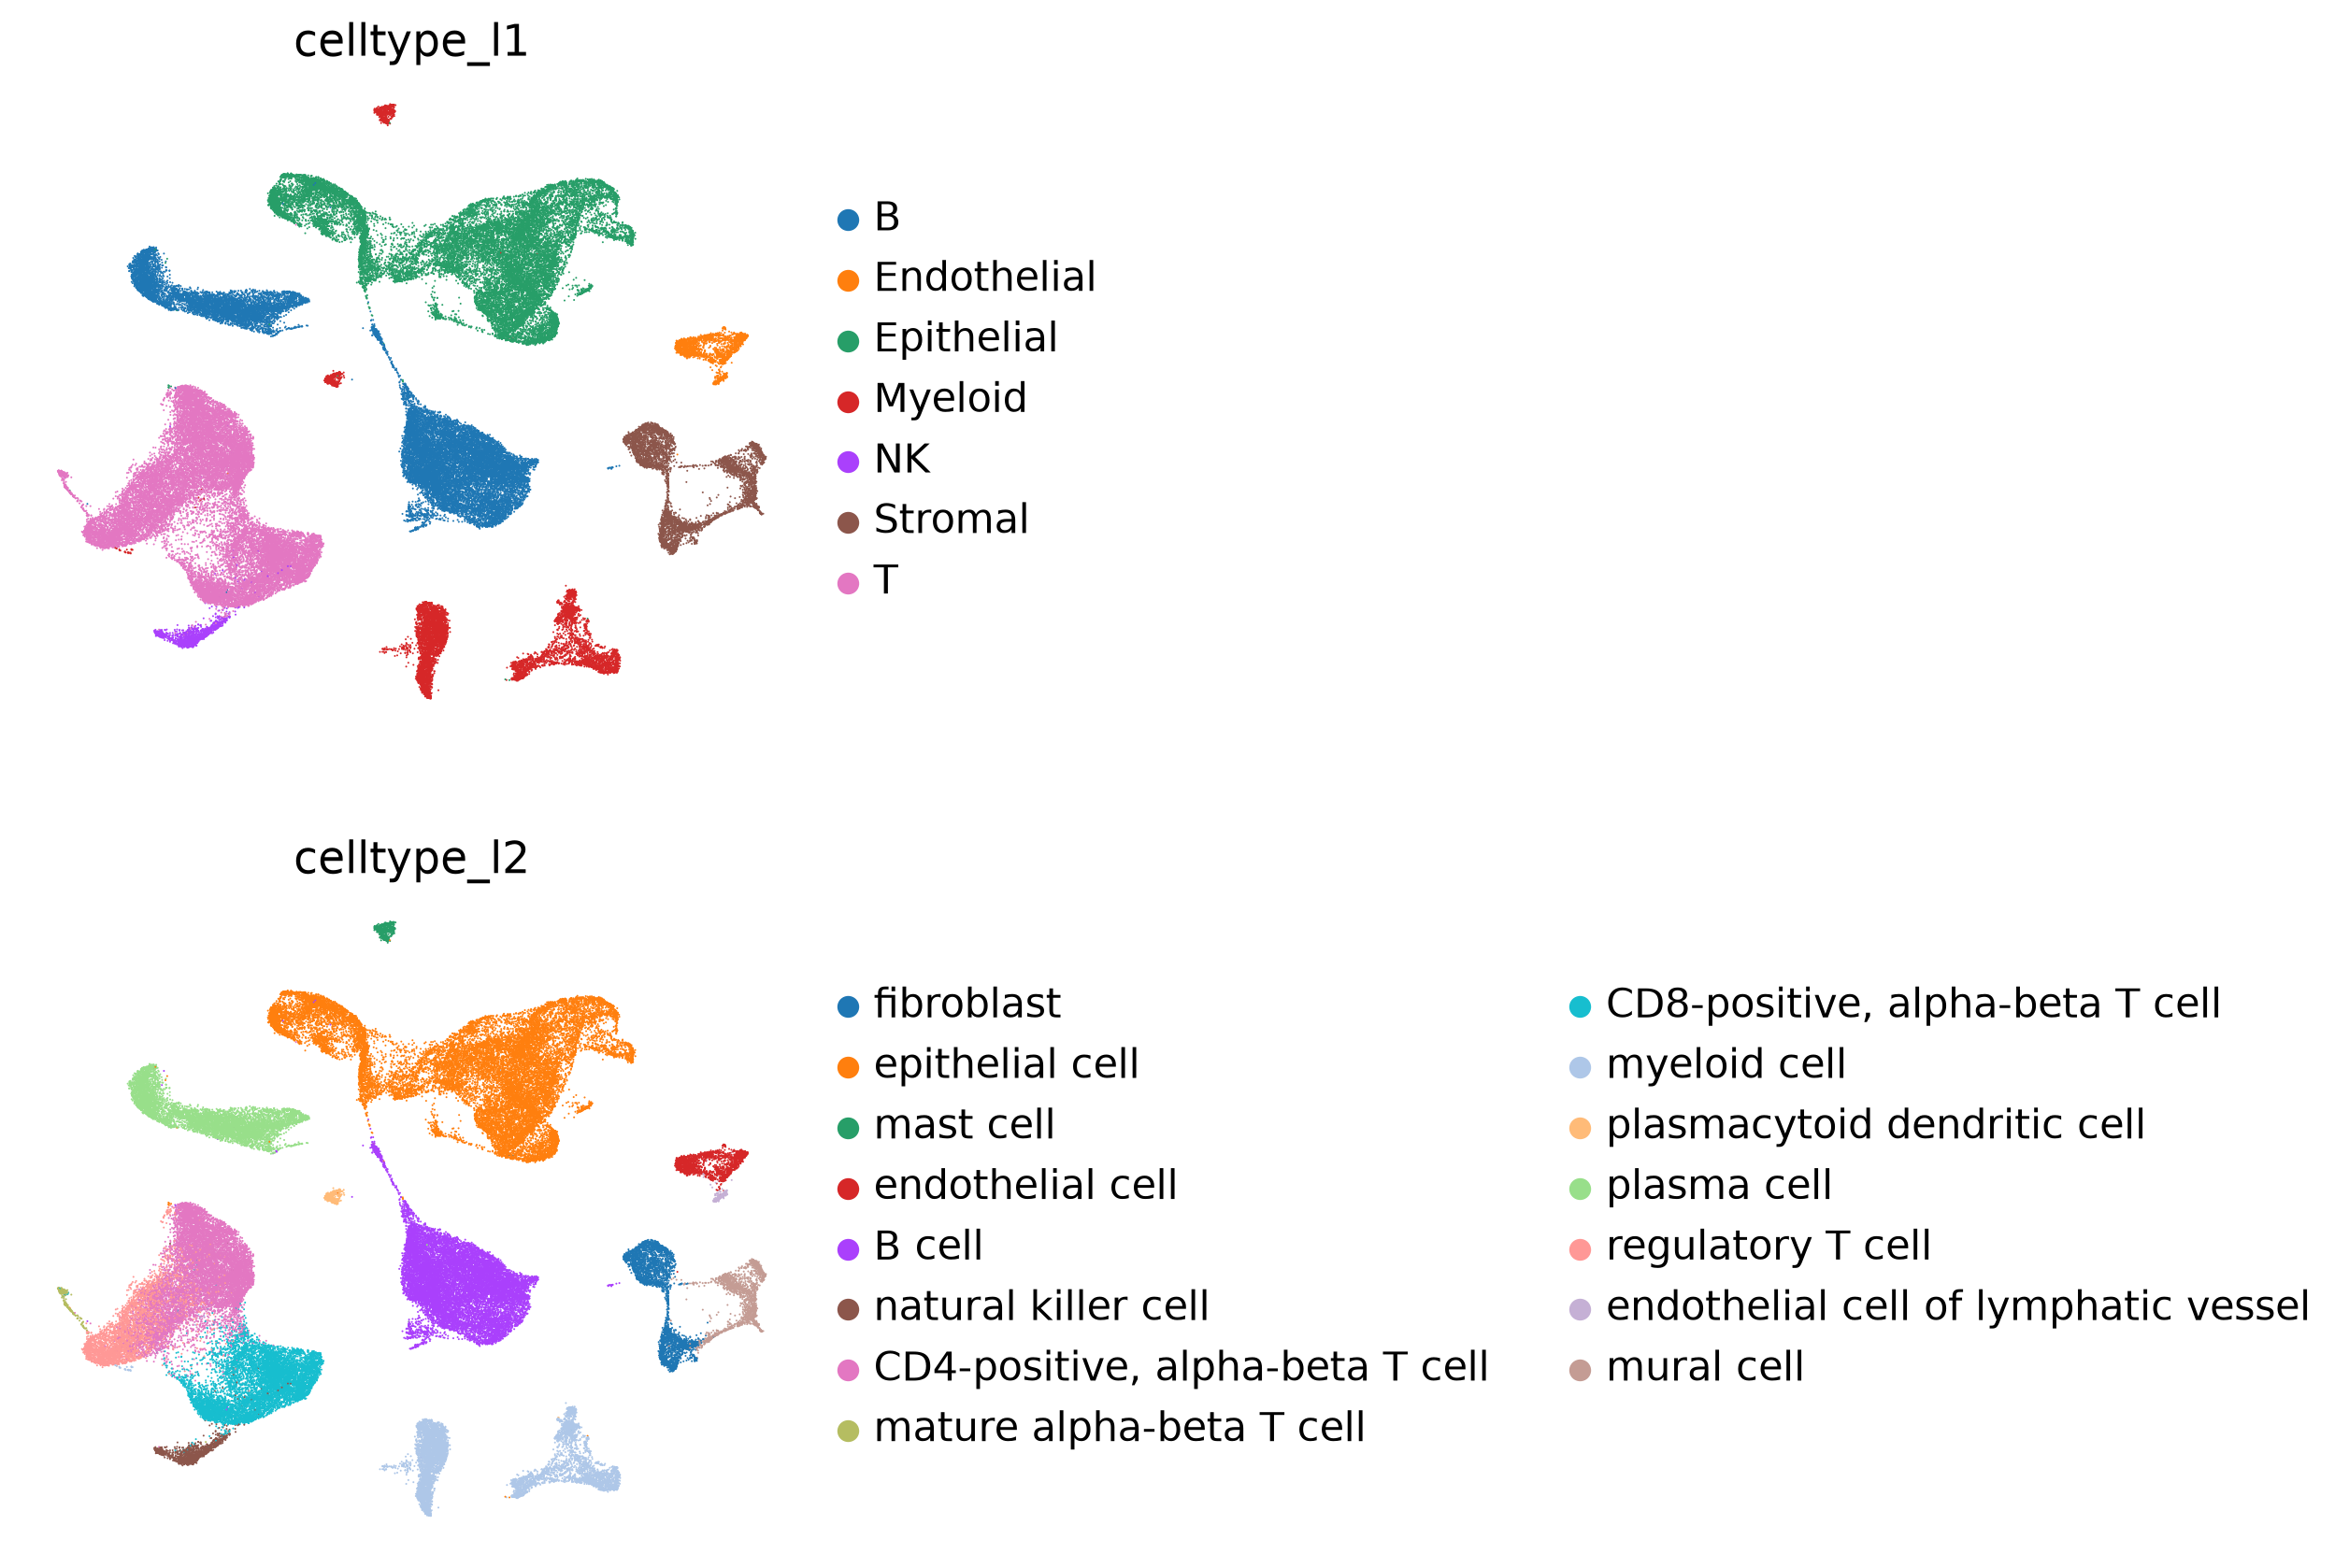

In [7]:
# Check annotations
sc.pl.umap(
    adata,
    color = [
        'celltype_l1',
        'celltype_l2'
    ],
    frameon = False,
    ncols = 1
)

In [8]:
# Create adata_train1, adata_train2 and adata_test datasets
adata_test = adata[adata.obs['donor_id'].isin(['HN481', 'HN482'])].copy()
adata_train = adata[adata.obs['donor_id'].isin(['HN483' 'HN485', 'HN488', 'HN489', 'HN490', 'HN487', 'HN492', 'HN494'])].copy()
del adata

In [9]:
# Normalize data
for i in [adata_train, adata_test]:
    i.layers['counts'] = i.X.copy()
    sc.pp.normalize_total(i, target_sum=None)
    sc.pp.log1p(i)

In [10]:
# Find highly variable features for scAdam model training
sc.pp.highly_variable_genes(
    adata_train,
    layer='counts',
    flavor='seurat_v3',
    n_top_genes=1200,
    subset=True
)

## Balanced training
We recommend balancing the dataset based on the most detailed annotation level—the last entry in the `celltype_keys` list, which is `celltype_l2` in this example. <br>
Balancing the training dataset can improve sensitivity, balanced accuracy, F1 score, and geometric mean, but may lead to a slight decrease in precision.

In [11]:
# Balance dataset based on most detailed annotation level
adata_balanced = scparadise.scnoah.balance(
    adata_train, 
    celltype_keys = ['celltype_l1', 'celltype_l2']
)

In [12]:
# Train scadam model using adata_balanced dataset
scparadise.scadam.train(
    adata_balanced,
    path = '', # path to save model
    model_name = 'model_scadam_balanced', # folder name with model
    celltype_keys = [
        'celltype_l1', # First (less detailed) annotation level
        'celltype_l2', # Second (most detailed) annotation level
    ],
    eval_metric = ['accuracy', 'balanced_accuracy']
)

Device: cuda
Number of features: 1200
Label hierarchy: celltype_l1 → celltype_l2
Annotation levels weights using strategy 'linear_offset':
  celltype_l1: 7 cell types, 0.4 relative weight
  celltype_l2: 15 cell types, 0.6 relative weight

Dataset split:
Train dataset contains: 36904 cells, it is 80.0 % of input dataset
Validation dataset contains: 9226 cells, it is 20.0 % of input dataset


Training scAdam model:   9%|█▌                | 18/200 [02:14<22:42,  7.49s/it]

Early stopping triggered! Best score: 0.9793
Training completed!
Fitting unknown cells detector


UnknownCellDetector fitted successfully!
Model saved to model_scadam_balanced


## Check model quality

In [13]:
# Predict cell types using trained model
adata_test = scparadise.scadam.predict(
    adata_test, 
    path_model = 'model_scadam_balanced'
)

Cell type annotation using the 2nd version of the scAdam model
scAdam model with unknown detector loaded from model_scadam_balanced
Gene alignment:
  Model features: 1200
  Matched features: 1200 (100.0%)


Predicting: 100%|█████████████████████████████| 72/72 [00:00<00:00, 170.65it/s]


Added cell type column: pred_celltype_l1
Added probabilities column: pred_celltype_l1_probability
Added cell type column: pred_celltype_l2
Added probabilities column: pred_celltype_l2_probability


In [14]:
# Add prediction status to adata_test
for i in ['l1', 'l2']:
    scparadise.scnoah.pred_status(
        adata_test, 
        celltype = 'celltype_' + i,
        pred_celltype = 'pred_celltype_' + i,
        key_added = 'pred_status_' + i
    )

In [15]:
# Order cell type colors
for i in ['l1', 'l2']:
    celltype = np.unique(adata_test.obs['celltype_' + i]).tolist()
    adata_test.obs['celltype_' + i] = pd.Categorical(
        values=adata_test.obs['celltype_' + i], categories=celltype, ordered=True
    )
    adata_test.obs['pred_celltype_' + i] = pd.Categorical(
        values=adata_test.obs['pred_celltype_' + i], categories=celltype, ordered=True
    )

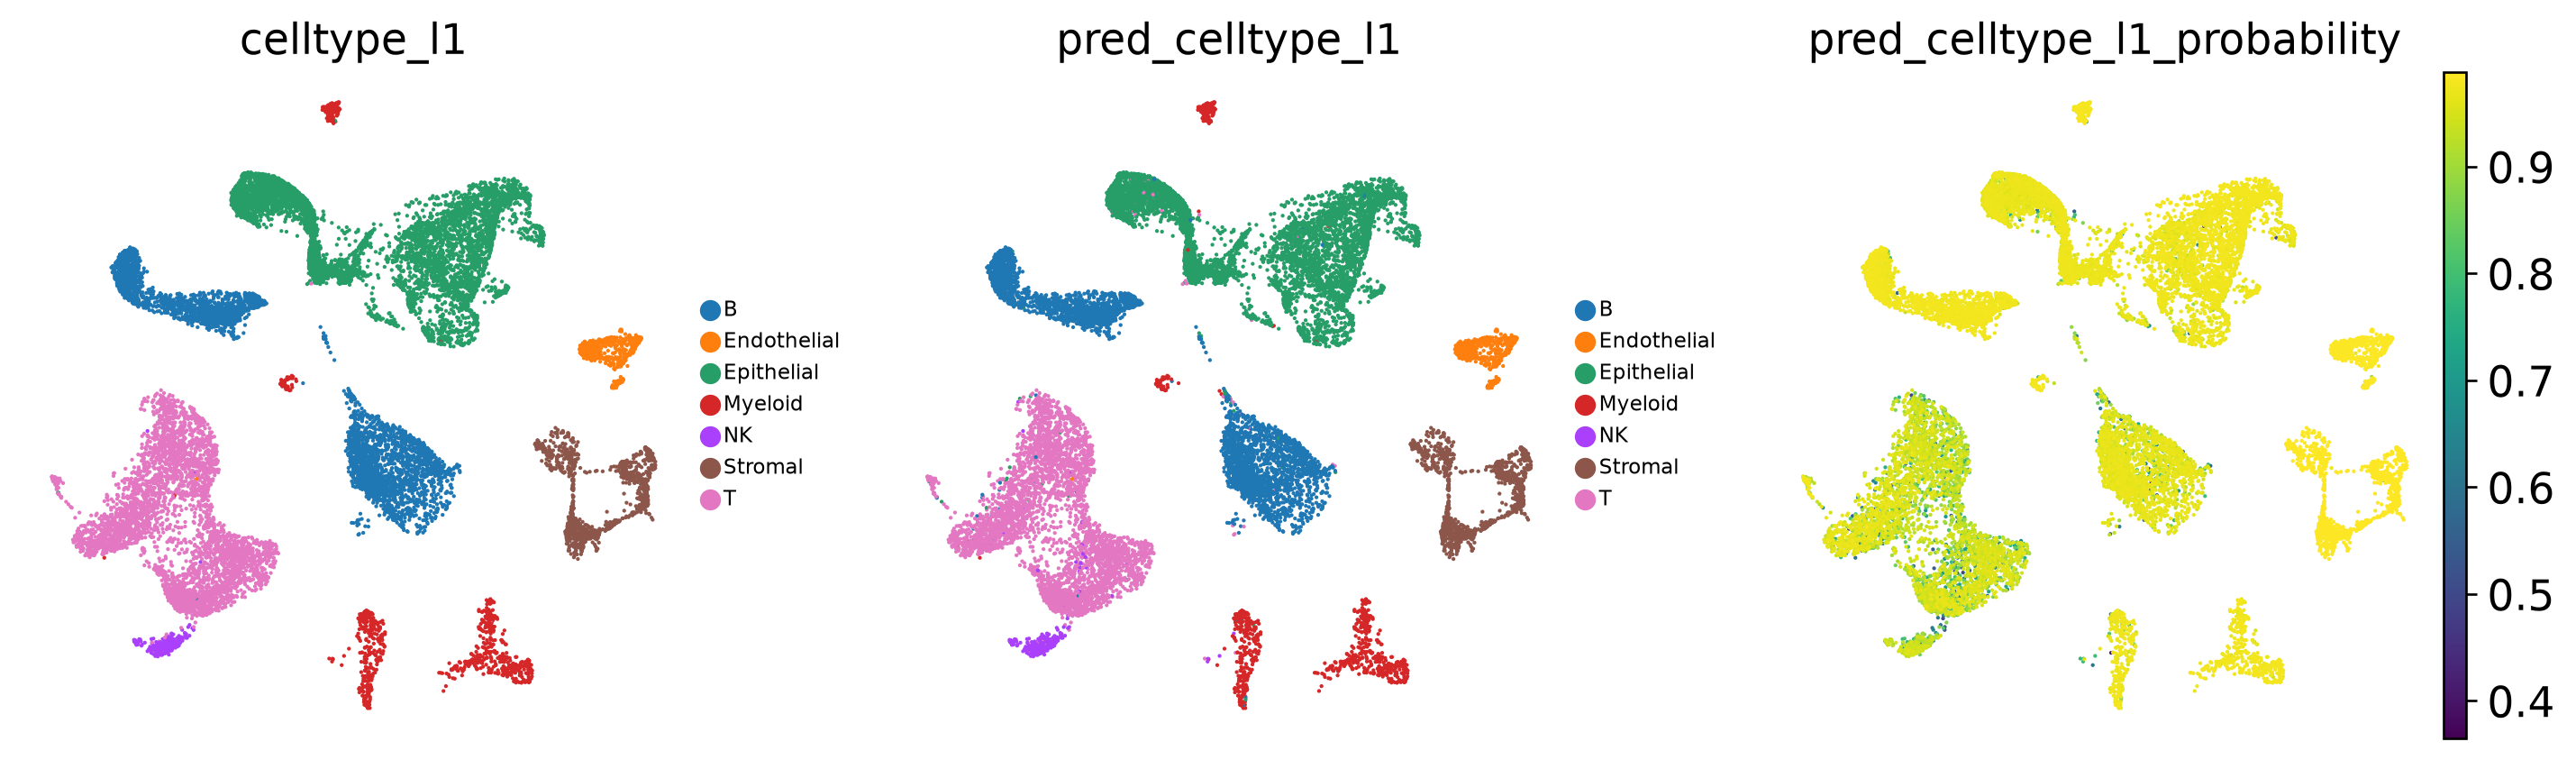

In [16]:
# Visualise predicted cell types (celltype_l1) and prediction probabilities
sc.pl.umap(
    adata_test, 
    color=[
        'celltype_l1', # observed cell type annotations
        'pred_celltype_l1', # predicted cell type annotations
        'pred_celltype_l1_probability' # prediction probabilities
    ],
    frameon = False,
    cmap = 'viridis',
    legend_loc = 'right margin',
    legend_fontsize = 7,
    legend_fontoutline = 1,
    ncols = 3,
    wspace = 0.2, 
    hspace = 0.1
)

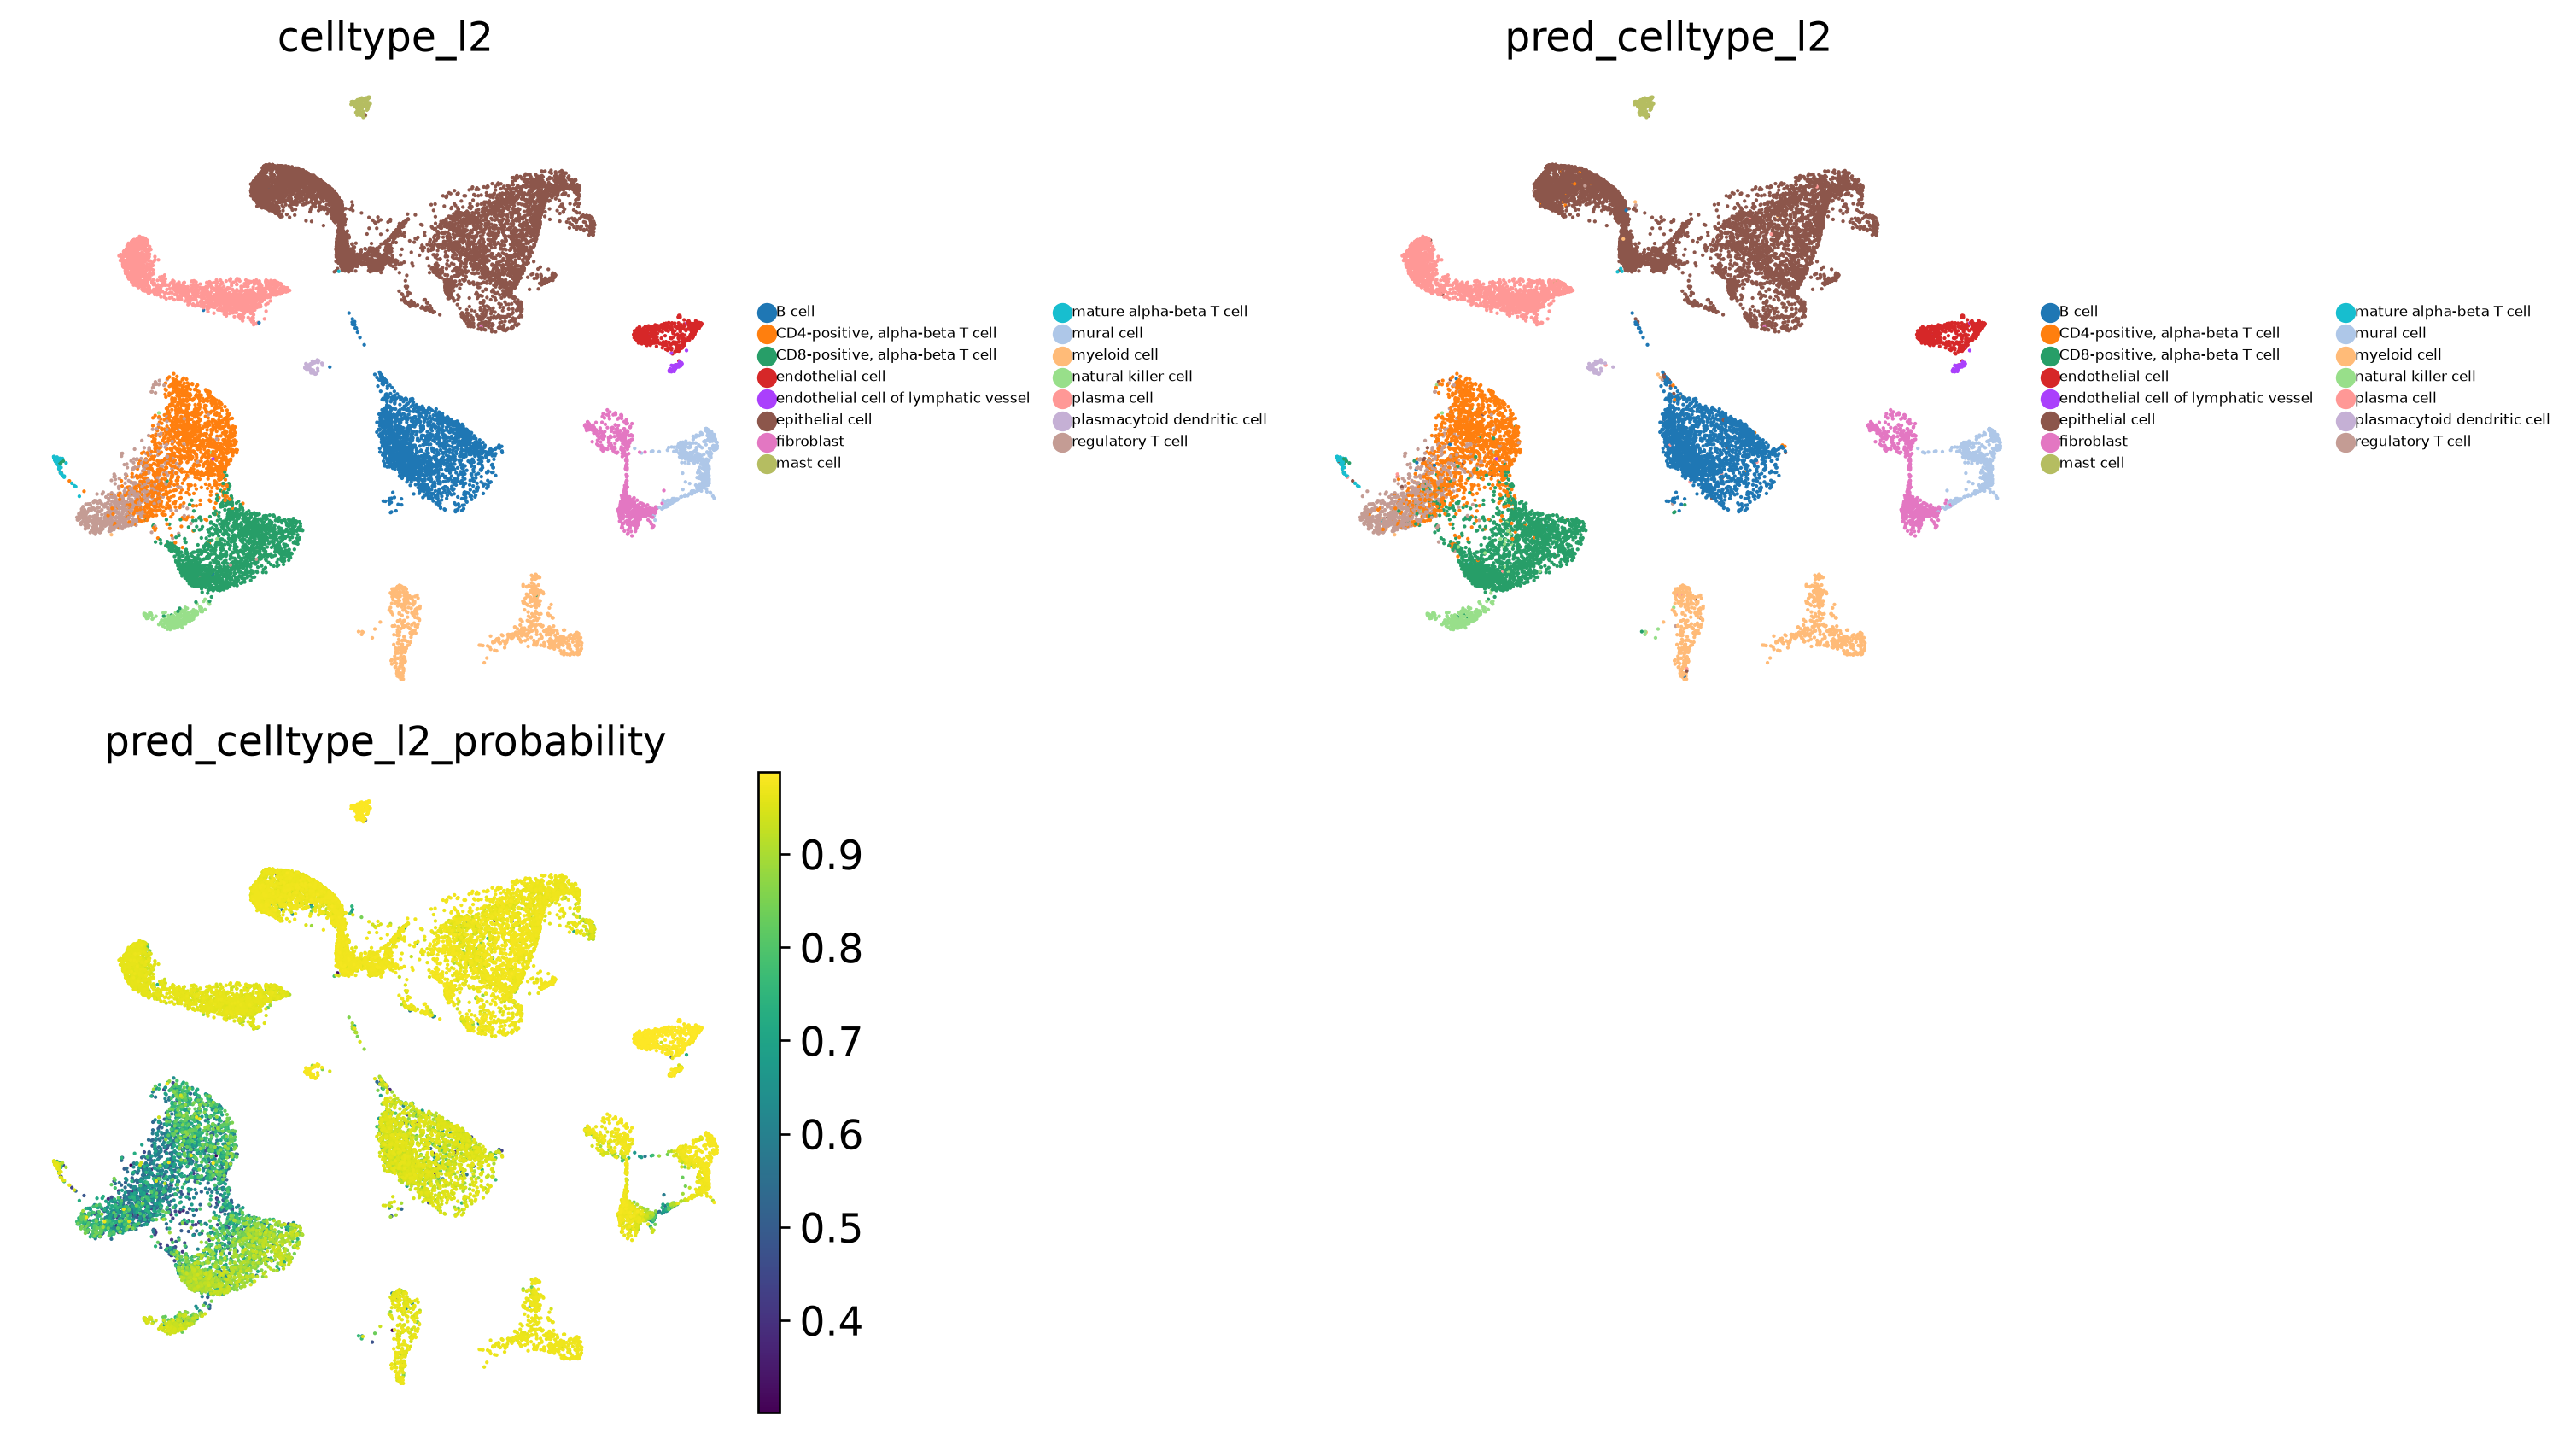

In [17]:
# Visualise predicted cell types (celltype_l2) and prediction probabilities
sc.pl.umap(
    adata_test, 
    color=[
        'celltype_l2', # observed cell type annotations
        'pred_celltype_l2', # predicted cell type annotations
        'pred_celltype_l2_probability' # prediction probabilities
    ],
    frameon = False,
    cmap = 'viridis',
    legend_loc = 'right margin',
    legend_fontsize = 5,
    legend_fontoutline = 1,
    ncols = 2,
    wspace = 0.6, 
    hspace = 0.1
)

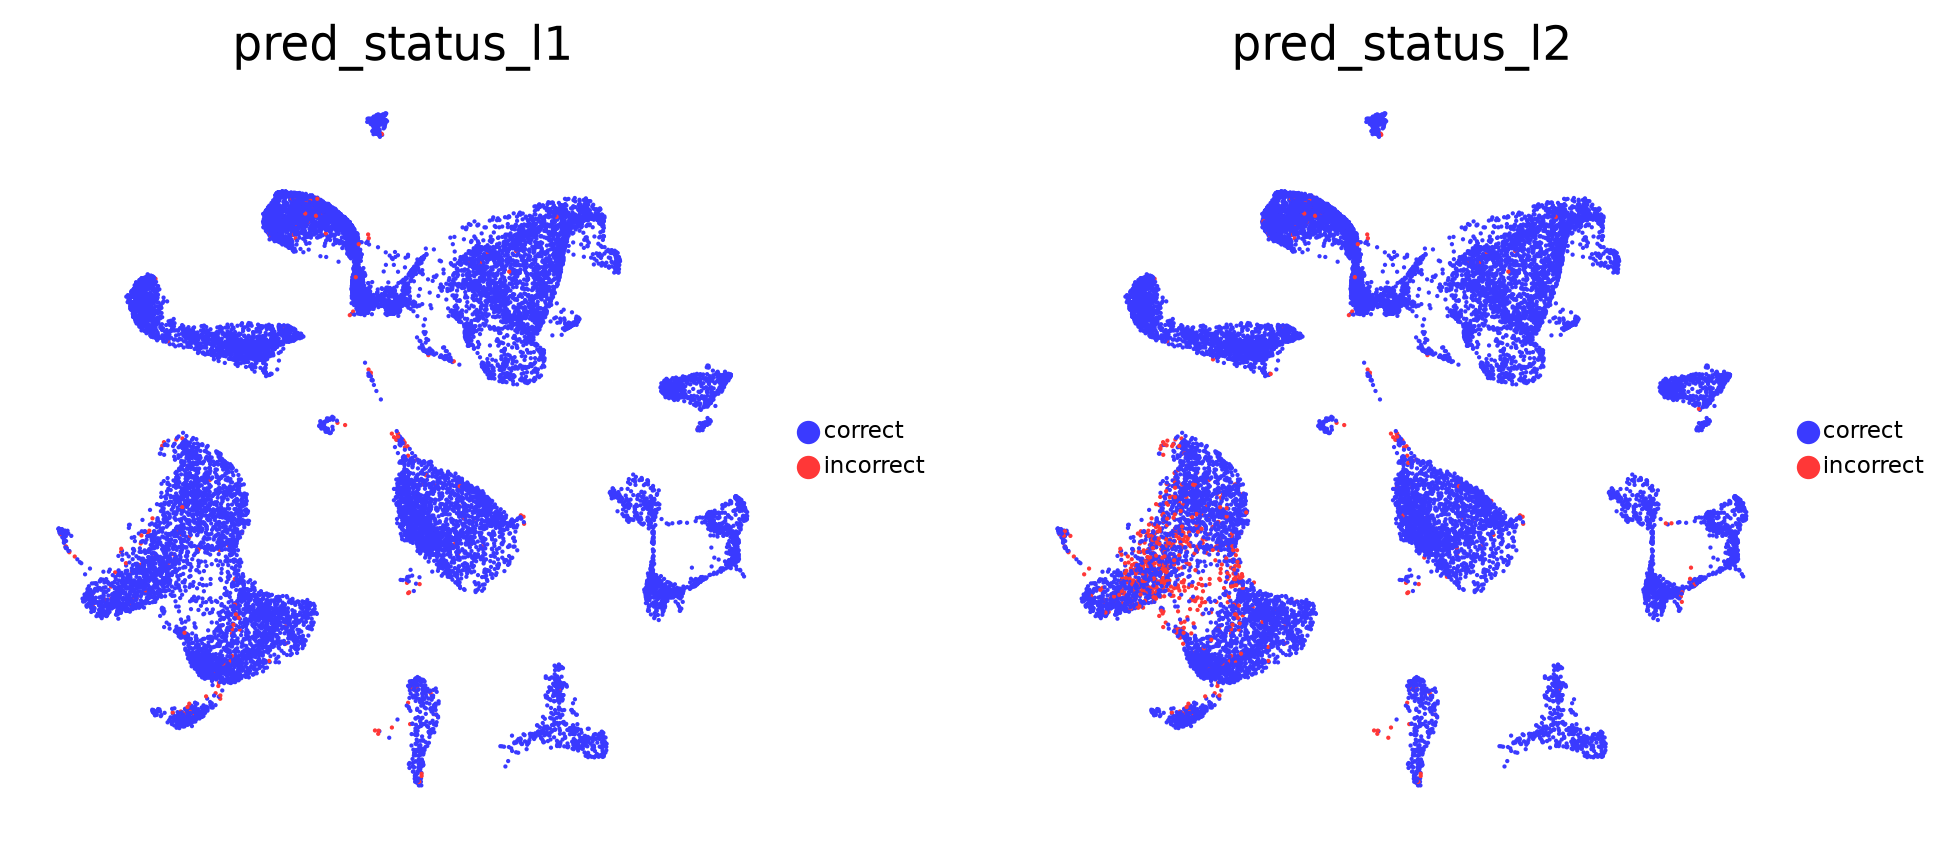

In [18]:
# Visualise prediction status
sc.pl.embedding(
    adata_test, 
    color=[
        'pred_status_l1',
        'pred_status_l2'
    ],
    basis = 'X_umap',
    frameon = False,
    cmap = 'viridis',
    legend_loc = 'right margin',
    legend_fontsize = 7,
    legend_fontoutline = 1,
    ncols = 3,
    wspace = 0.2, 
    hspace = 0.1
)

The probability and prediction status analysis indicates issues with the model in annotating `T cell subtypes` at the `celltype_l2` annotation level. However, the model does not have problems with annotating other cell types, as confirmed by the quality analysis presented below.

### Comparizon of observed and predicted cell type annotations
To compare the actual and predicted cell types, we use `report_classif_full` and `conf_matrix` from the scNoah module. <br>
More information about the metrics in `scparadise.scnoah.report_classif_full` is available in the [scParadise documentation](https://scparadise.readthedocs.io/en/latest/theory.html#scnoah-metrics). <br>
More information about confusion matrix (`scparadise.scnoah.conf_matrix`) is available [here](https://scikit-learn.org/dev/modules/generated/sklearn.metrics.confusion_matrix.html).

In [19]:
# First annotation level (celltype_l1)
df_l1 = scparadise.scnoah.report_classif_full(
    adata_test,
    celltype = 'celltype_l1',
    pred_celltype = 'pred_celltype_l1',
    ndigits = 3
)
df_l1

,precision,recall/sensitivity,specificity,f1-score,geometric mean,index balanced accuracy,number of cells
B,0.991,0.986,0.998,0.989,0.992,0.983,3969
Endothelial,0.998,0.998,1.0,0.998,0.999,0.998,509
Epithelial,0.992,0.99,0.994,0.991,0.992,0.984,7505
Myeloid,0.979,0.981,0.999,0.98,0.99,0.978,924
NK,0.843,0.96,0.998,0.897,0.979,0.954,223
Stromal,0.999,1.0,1.0,1.0,1.0,1.0,1113
T,0.979,0.979,0.994,0.979,0.987,0.972,4057
macro avg,0.969,0.985,0.998,0.976,0.991,0.981,
weighted avg,0.987,0.987,0.996,0.987,0.991,0.982,
Accuracy,0.987,,,,,,


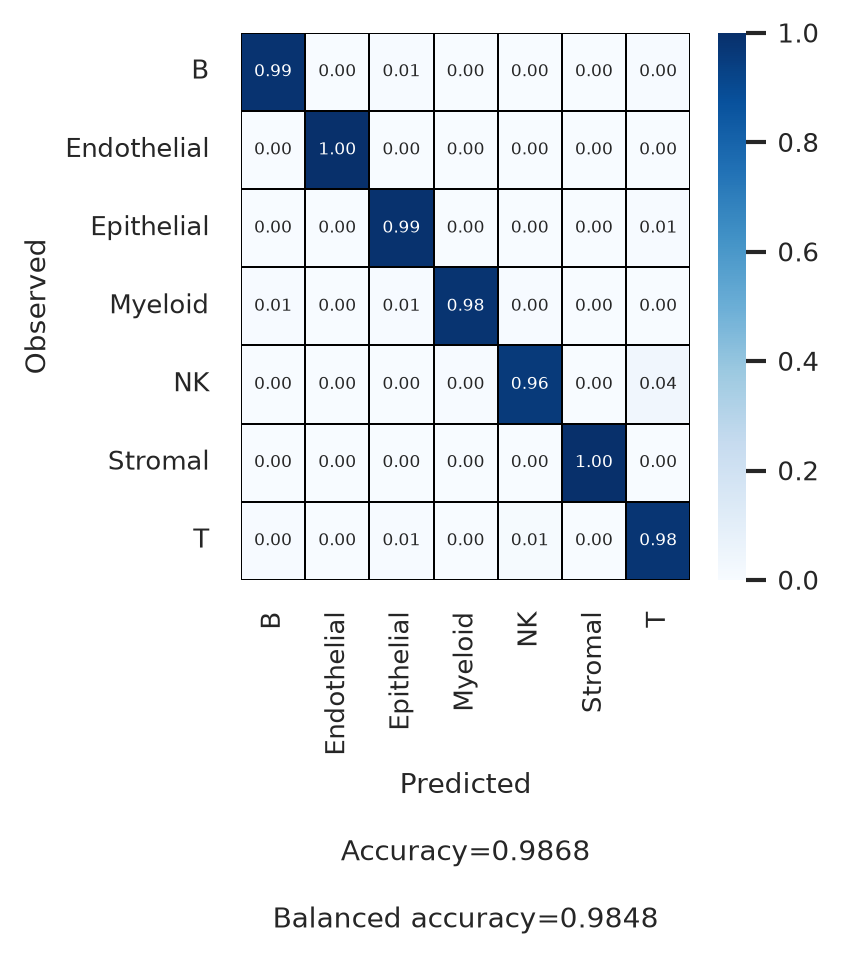

In [20]:
sns.set(font_scale = 0.7)
plt.figure(figsize = (3, 3))
scparadise.scnoah.conf_matrix(
    adata_test,
    celltype = 'celltype_l1',
    pred_celltype = 'pred_celltype_l1',
    annot_kws = {"size":5},
    linewidths = 0.1, linecolor = 'black',
    fmt =  ".2f",
    ndigits_metrics = 4,
    vmin = 0, vmax = 1
)

In [21]:
# Second annotation level (celltype_l2)
df_l2 = scparadise.scnoah.report_classif_full(
    adata_test,
    celltype = 'celltype_l2',
    pred_celltype = 'pred_celltype_l2',
    ndigits = 3
)
df_l2

,precision,recall/sensitivity,specificity,f1-score,geometric mean,index balanced accuracy,number of cells
B cell,0.995,0.971,0.999,0.983,0.985,0.968,2050
"CD4-positive, alpha-beta T cell",0.861,0.801,0.988,0.83,0.89,0.777,1554
"CD8-positive, alpha-beta T cell",0.917,0.949,0.991,0.933,0.97,0.936,1742
endothelial cell,0.996,1.0,1.0,0.998,1.0,1.0,457
endothelial cell of lymphatic vessel,1.000,0.981,1.0,0.99,0.99,0.979,52
epithelial cell,0.991,0.991,0.994,0.991,0.992,0.985,7505
fibroblast,0.982,0.994,0.999,0.988,0.997,0.993,676
mast cell,0.986,0.986,1.0,0.986,0.993,0.985,148
mature alpha-beta T cell,0.868,0.88,0.999,0.874,0.938,0.869,75
mural cell,0.991,0.973,1.0,0.982,0.986,0.97,437


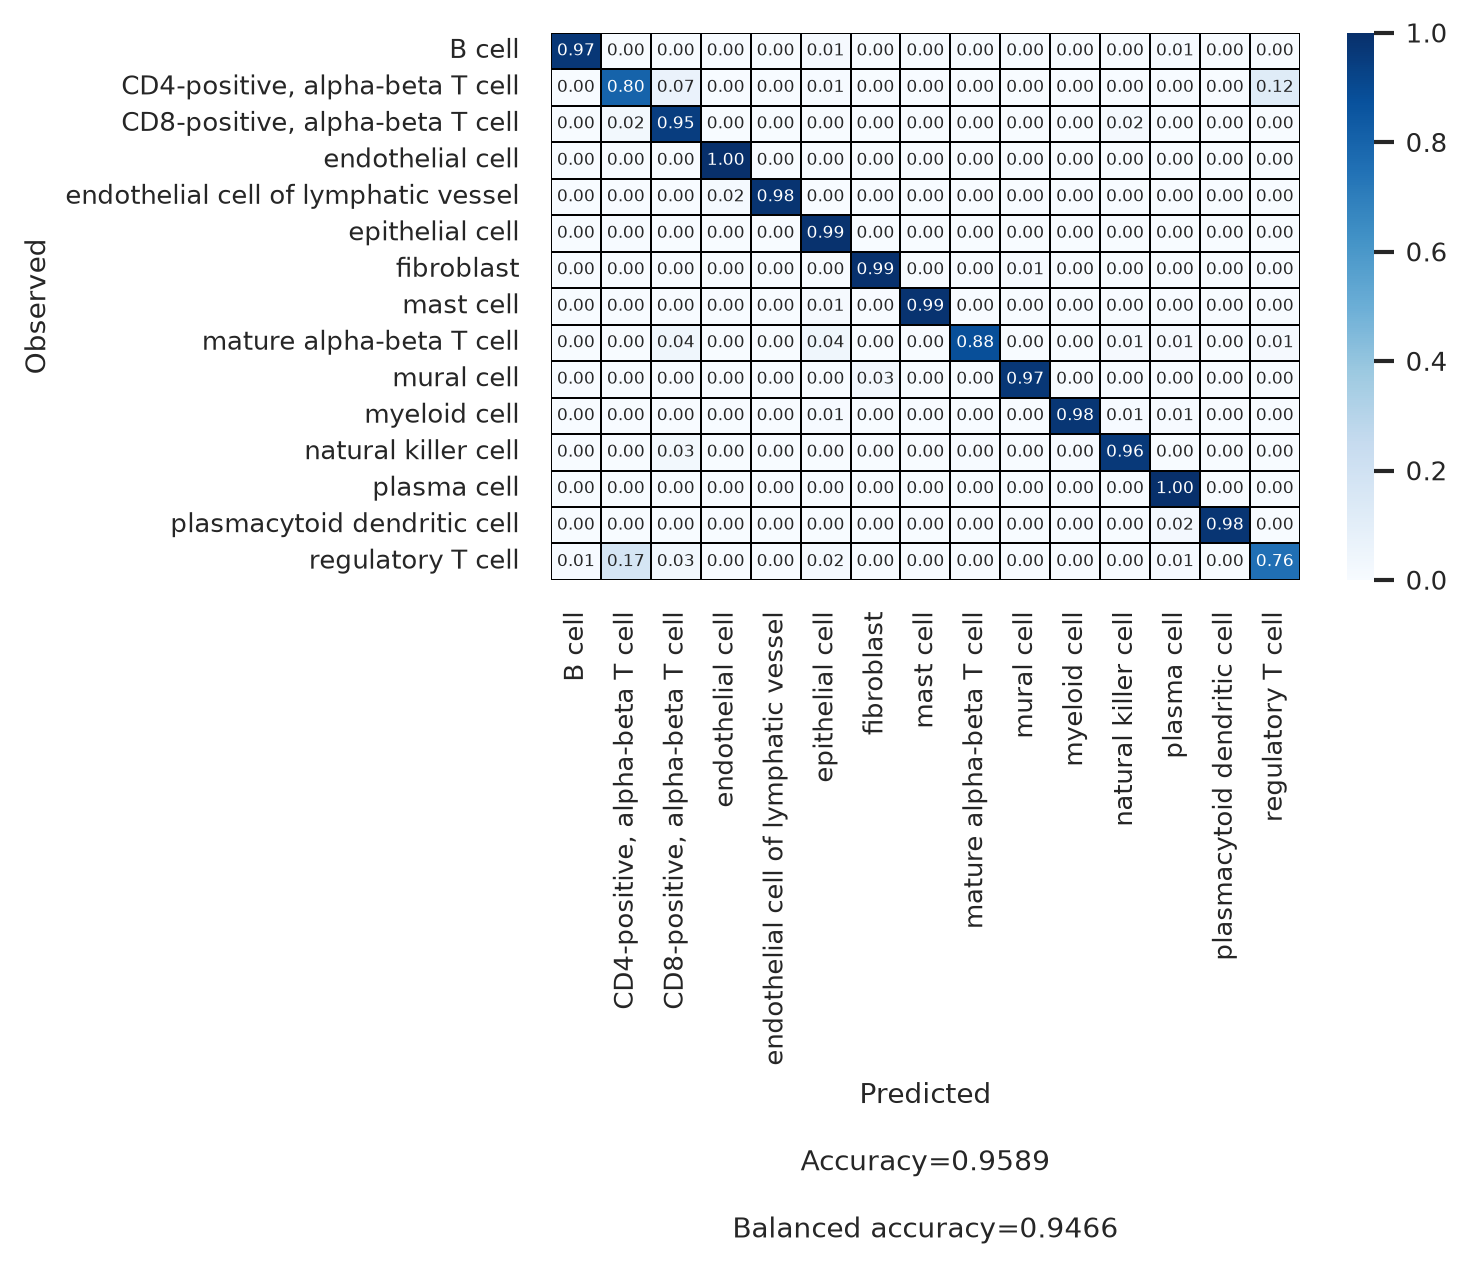

In [22]:
sns.set(font_scale = 0.7)
plt.figure(figsize = (5, 3))
scparadise.scnoah.conf_matrix(
    adata_test,
    celltype = 'celltype_l2',
    pred_celltype = 'pred_celltype_l2',
    annot_kws = {"size":5},
    linewidths = 0.1, linecolor = 'black',
    fmt =  ".2f",
    ndigits_metrics = 4,
    vmin = 0, vmax = 1
)

In [23]:
# Save anndata with predicted annotations
adata_test.write_h5ad('adata_test_balanced_model.h5ad')

## Imbalanced training
Use 'balanced_accuracy' as evaluation metric in case of imbalanced learning

In [24]:
# Train scadam model using adata_train dataset
scparadise.scadam.train(
    adata_balanced,
    path = '', # path to save model
    model_name = 'model_scadam_imbalanced', # folder name with model
    celltype_keys = [
        'celltype_l1', # First (less detailed) annotation level
        'celltype_l2', # Second (most detailed) annotation level
    ],
    eval_metric = ['accuracy', 'balanced_accuracy']
)

Device: cuda
Number of features: 1200
Label hierarchy: celltype_l1 → celltype_l2
Annotation levels weights using strategy 'linear_offset':
  celltype_l1: 7 cell types, 0.4 relative weight
  celltype_l2: 15 cell types, 0.6 relative weight

Dataset split:
Train dataset contains: 36904 cells, it is 80.0 % of input dataset
Validation dataset contains: 9226 cells, it is 20.0 % of input dataset


Training scAdam model:   9%|█▌                | 18/200 [02:13<22:34,  7.44s/it]

Early stopping triggered! Best score: 0.9793
Training completed!
Fitting unknown cells detector


UnknownCellDetector fitted successfully!
Model saved to model_scadam_imbalanced


## Check model quality

In [25]:
# Predict cell types using trained model
adata_test = scparadise.scadam.predict(
    adata_test, 
    path_model = 'model_scadam_imbalanced'
)

Cell type annotation using the 2nd version of the scAdam model
scAdam model with unknown detector loaded from model_scadam_imbalanced
Gene alignment:
  Model features: 1200
  Matched features: 1200 (100.0%)


Predicting: 100%|█████████████████████████████| 72/72 [00:00<00:00, 152.04it/s]


Added cell type column: pred_celltype_l1
Added probabilities column: pred_celltype_l1_probability
Added cell type column: pred_celltype_l2
Added probabilities column: pred_celltype_l2_probability


In [26]:
# Add prediction status to adata_test
for i in ['l1', 'l2']:
    scparadise.scnoah.pred_status(
        adata_test, 
        celltype = 'celltype_' + i,
        pred_celltype = 'pred_celltype_' + i,
        key_added = 'pred_status_' + i
    )

In [27]:
# Order cell type colors
for i in ['l1', 'l2']:
    celltype = np.unique(adata_test.obs['celltype_' + i]).tolist()
    adata_test.obs['celltype_' + i] = pd.Categorical(
        values=adata_test.obs['celltype_' + i], categories=celltype, ordered=True
    )
    adata_test.obs['pred_celltype_' + i] = pd.Categorical(
        values=adata_test.obs['pred_celltype_' + i], categories=celltype, ordered=True
    )

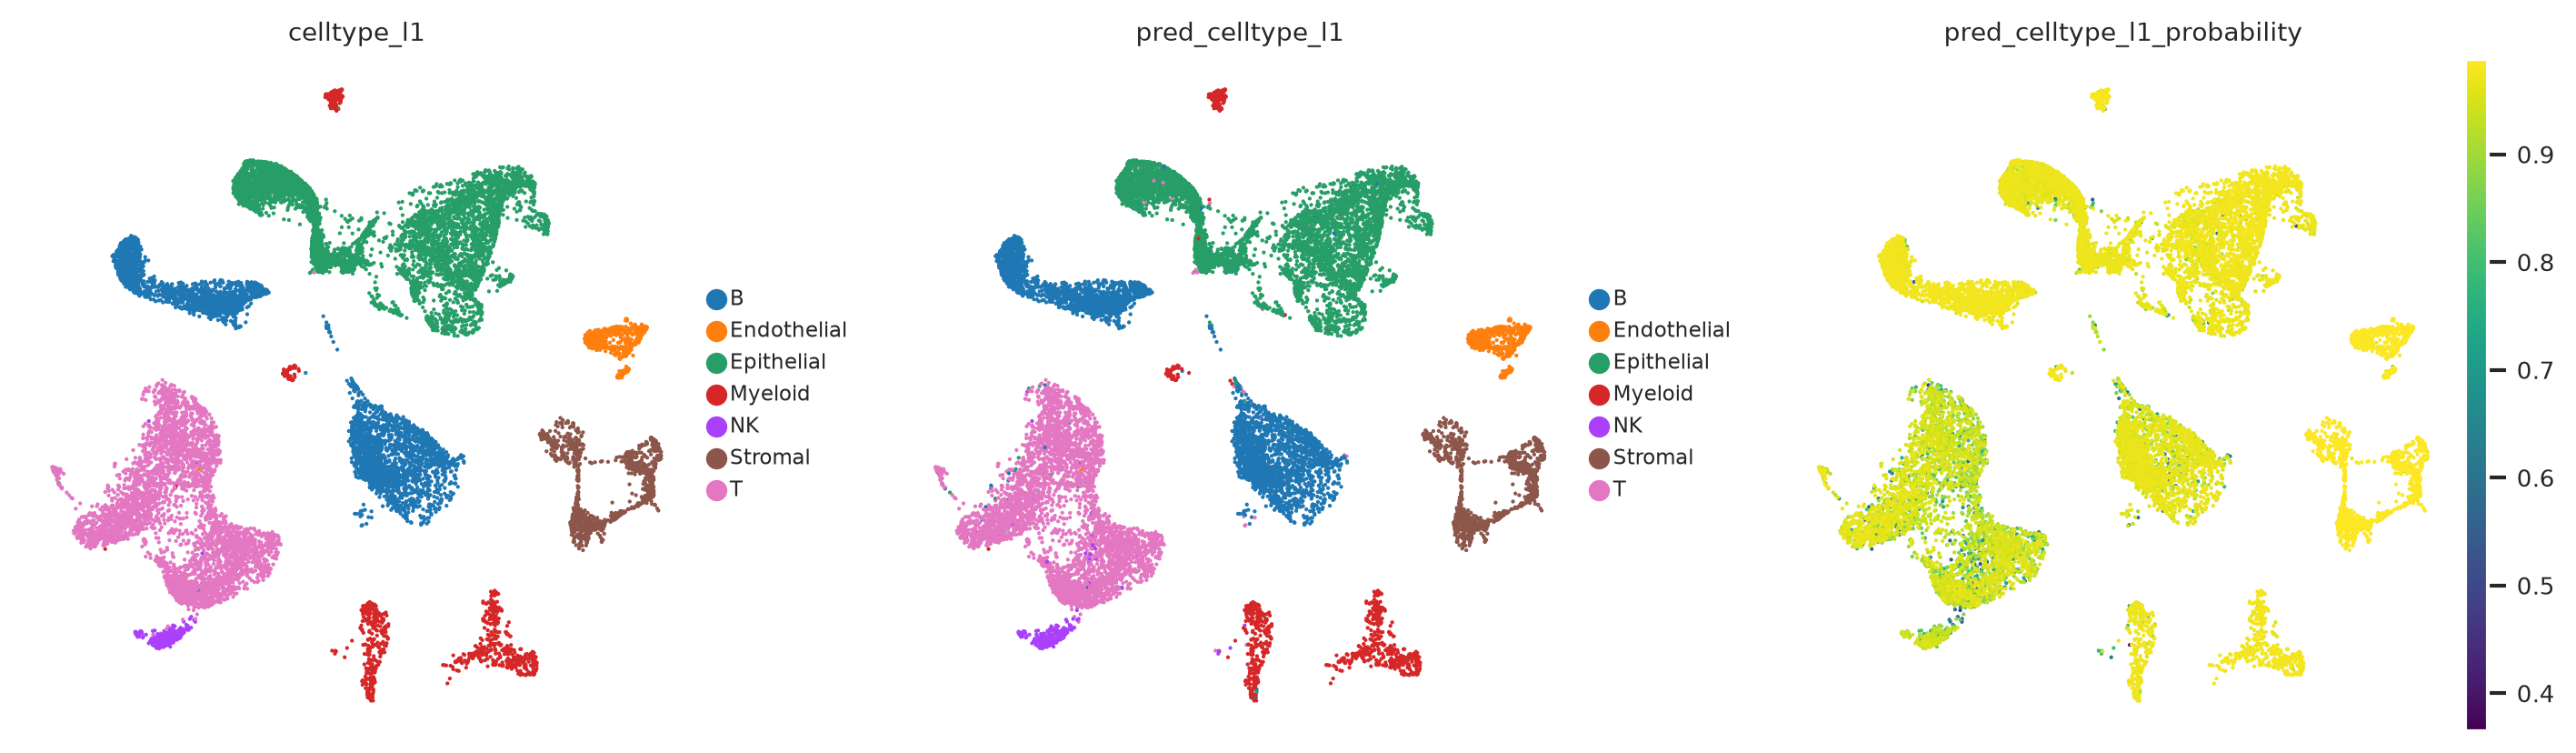

In [28]:
# Visualise predicted cell types (celltype_l1) and prediction probabilities
sc.pl.umap(
    adata_test, 
    color=[
        'celltype_l1', # observed cell type annotations
        'pred_celltype_l1', # predicted cell type annotations
        'pred_celltype_l1_probability' # prediction probabilities
    ],
    frameon = False,
    cmap = 'viridis',
    legend_loc = 'right margin',
    legend_fontsize = 7,
    legend_fontoutline = 1,
    ncols = 3,
    wspace = 0.2, 
    hspace = 0.1
)

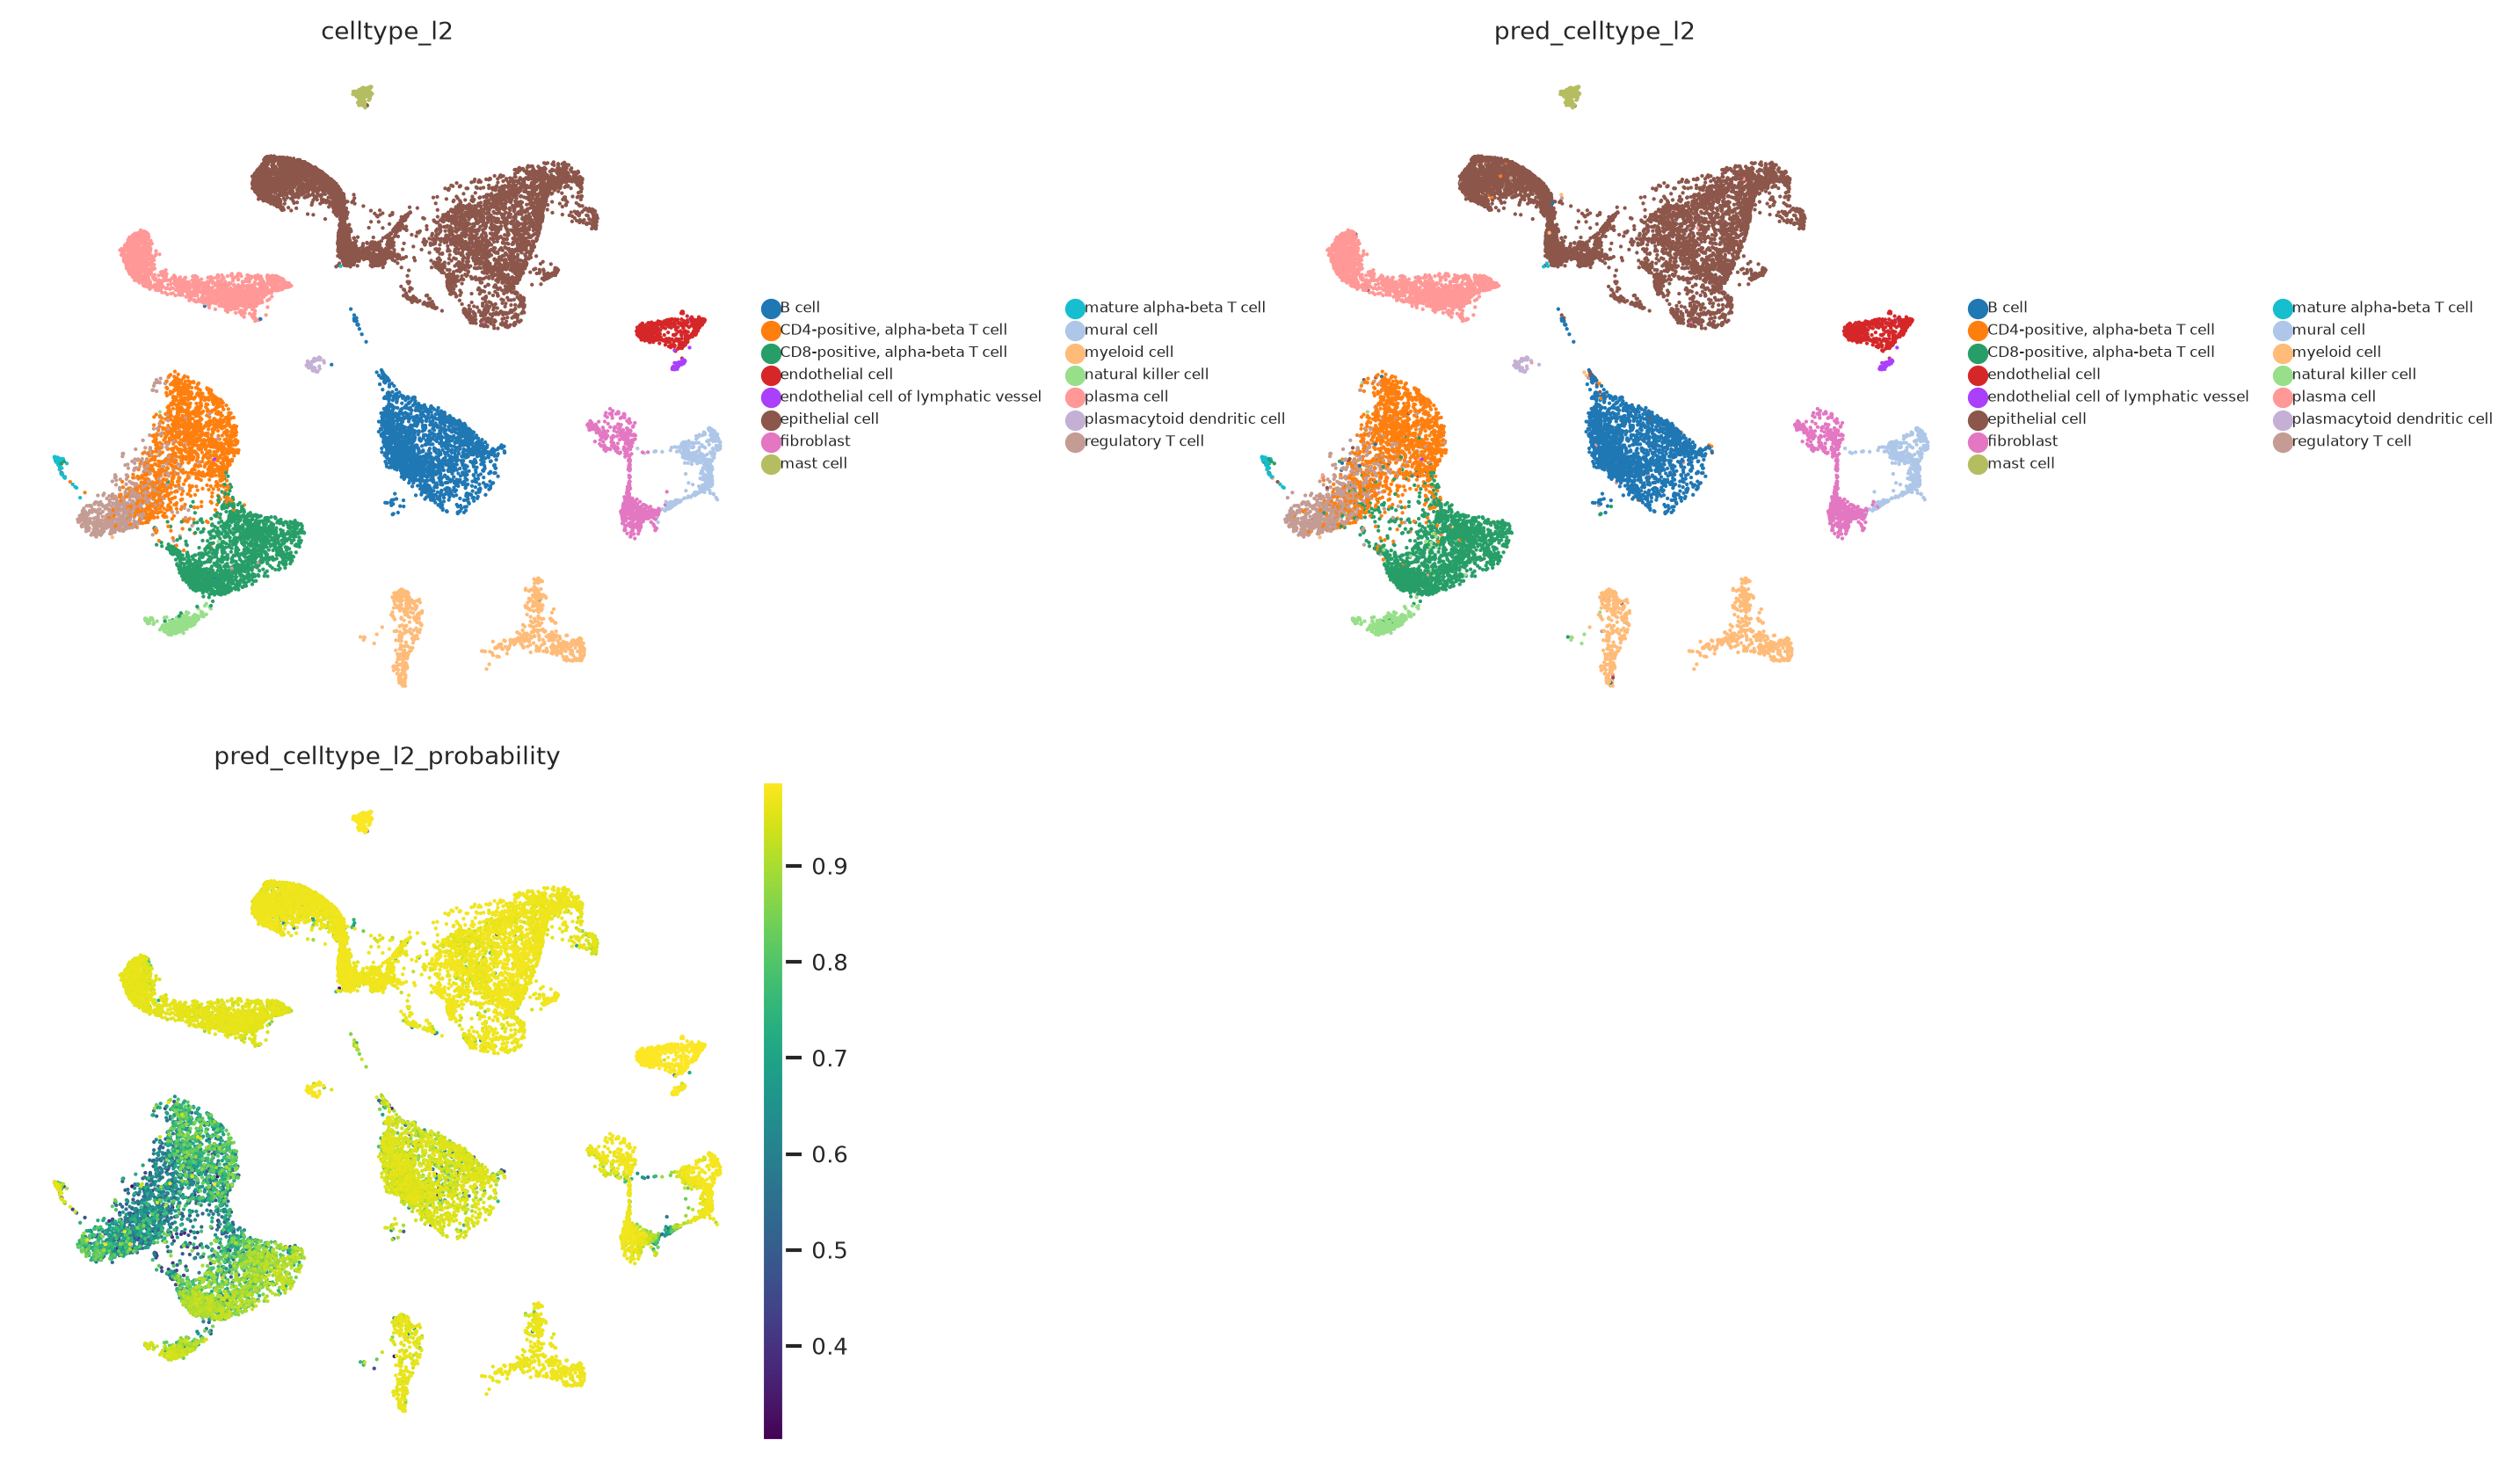

In [29]:
# Visualise predicted cell types (celltype_l2) and prediction probabilities
sc.pl.umap(
    adata_test, 
    color=[
        'celltype_l2', # observed cell type annotations
        'pred_celltype_l2', # predicted cell type annotations
        'pred_celltype_l2_probability' # prediction probabilities
    ],
    frameon = False,
    cmap = 'viridis',
    legend_loc = 'right margin',
    legend_fontsize = 5,
    legend_fontoutline = 1,
    ncols = 2,
    wspace = 0.5, 
    hspace = 0.1
)

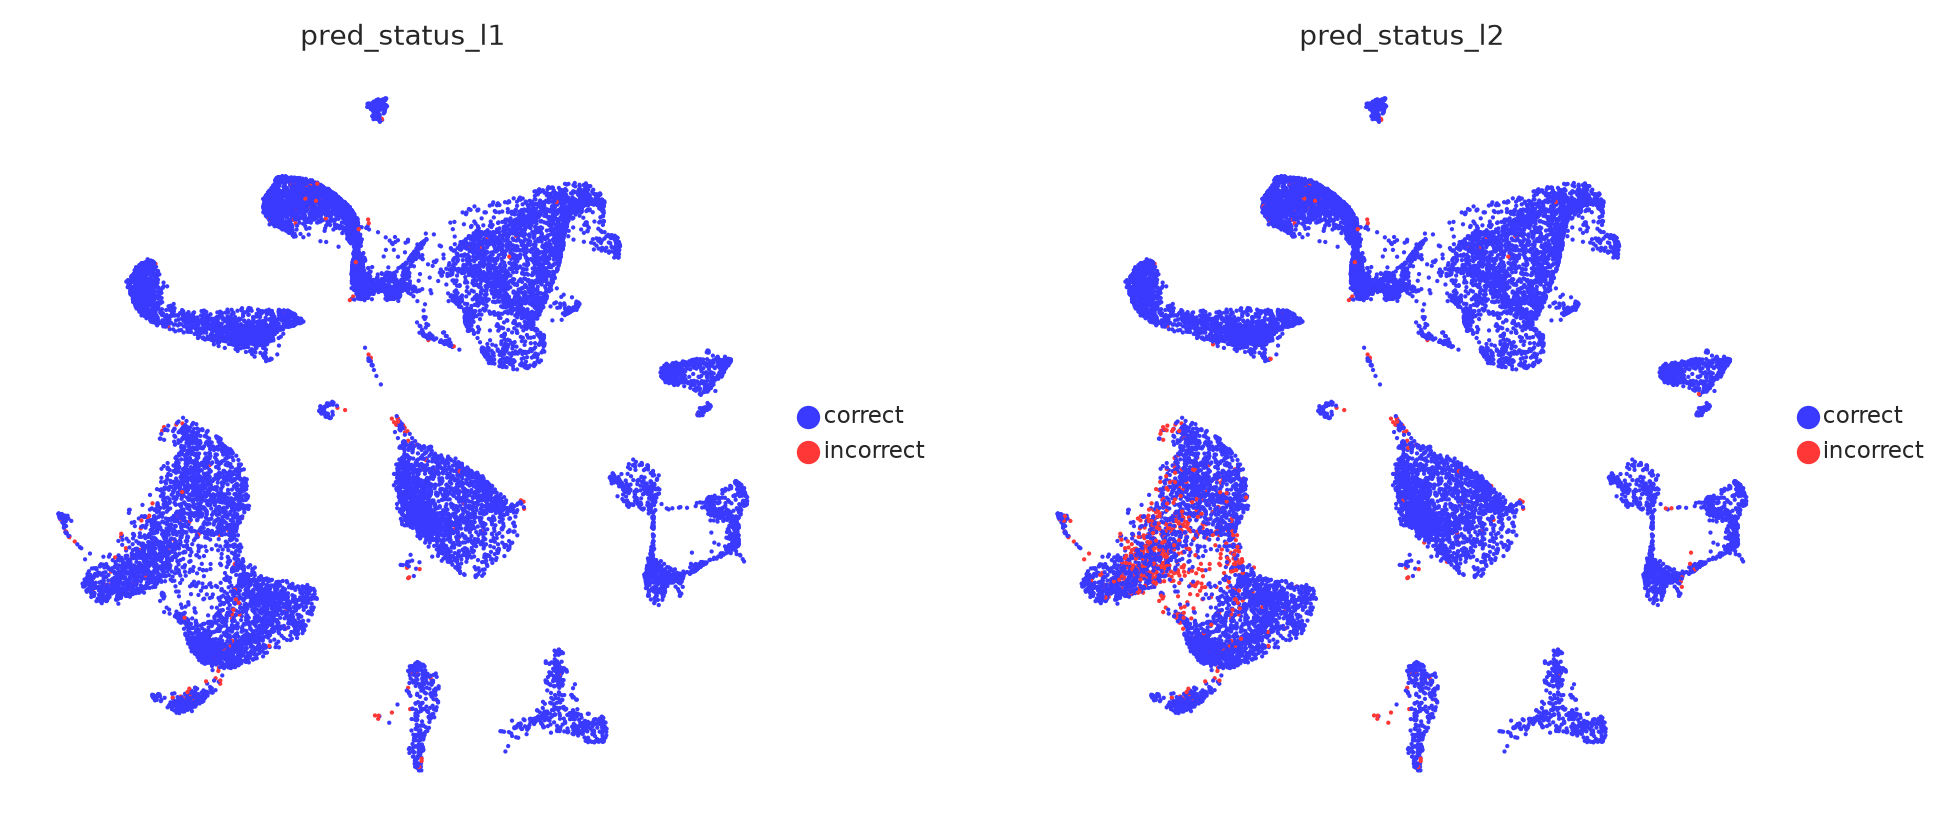

In [30]:
# Visualise prediction status
sc.pl.embedding(
    adata_test, 
    color=[
        'pred_status_l1',
        'pred_status_l2'
    ],
    basis = 'X_umap',
    frameon = False,
    cmap = 'viridis',
    legend_loc = 'right margin',
    legend_fontsize = 7,
    legend_fontoutline = 1,
    ncols = 3,
    wspace = 0.2, 
    hspace = 0.1
)

The probability and prediction status analysis indicates issues with the model in annotating T cell subtypes at the celltype_l2 annotation level. However, the model does not have problems with annotating other cell types, as confirmed by the quality analysis presented below.

### Comparizon of observed and predicted cell type annotations
To compare the actual and predicted cell types, we use `report_classif_full` and `conf_matrix` from the scNoah module. <br>
More information about the metrics in `scparadise.scnoah.report_classif_full` is available in the [scParadise documentation](https://scparadise.readthedocs.io/en/latest/theory.html#scnoah-metrics). <br>
More information about confusion matrix (`scparadise.scnoah.conf_matrix`) is available [here](https://scikit-learn.org/dev/modules/generated/sklearn.metrics.confusion_matrix.html).

In [31]:
# First annotation level (celltype_l1)
df_l1 = scparadise.scnoah.report_classif_full(
    adata_test,
    celltype='celltype_l1',
    pred_celltype='pred_celltype_l1',
    ndigits = 3
)
df_l1

,precision,recall/sensitivity,specificity,f1-score,geometric mean,index balanced accuracy,number of cells
B,0.991,0.986,0.998,0.989,0.992,0.983,3969
Endothelial,0.998,0.998,1.0,0.998,0.999,0.998,509
Epithelial,0.992,0.99,0.994,0.991,0.992,0.984,7505
Myeloid,0.979,0.981,0.999,0.98,0.99,0.978,924
NK,0.843,0.96,0.998,0.897,0.979,0.954,223
Stromal,0.999,1.0,1.0,1.0,1.0,1.0,1113
T,0.979,0.979,0.994,0.979,0.987,0.972,4057
macro avg,0.969,0.985,0.998,0.976,0.991,0.981,
weighted avg,0.987,0.987,0.996,0.987,0.991,0.982,
Accuracy,0.987,,,,,,


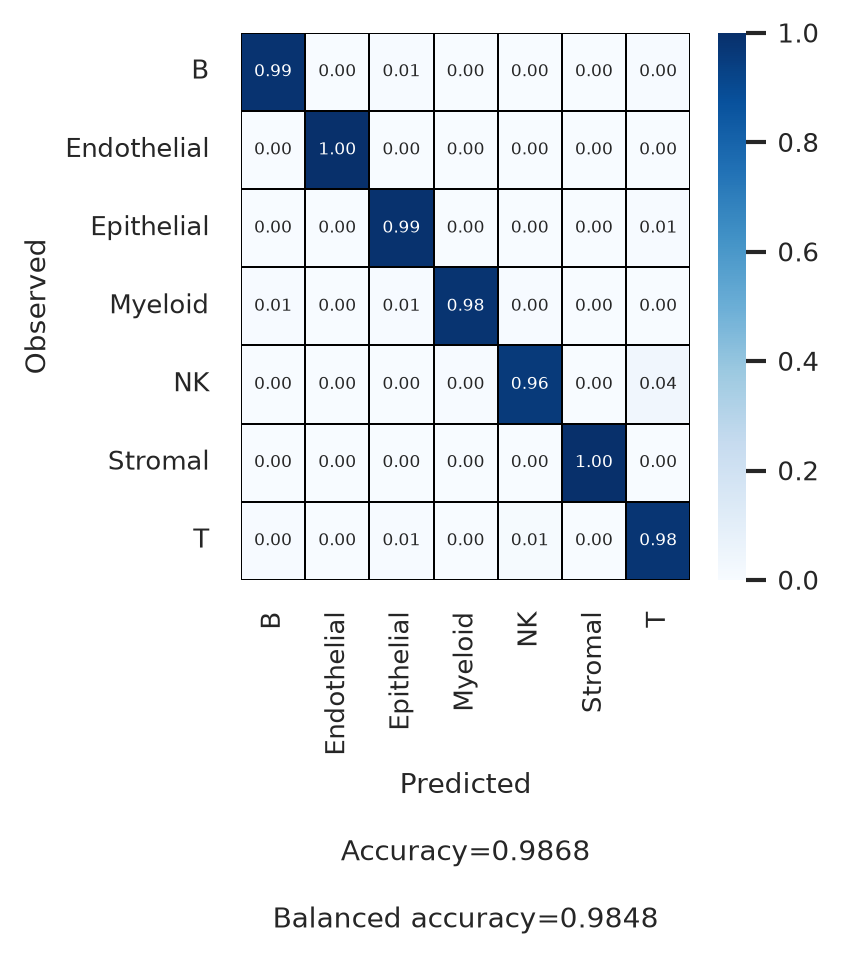

In [32]:
sns.set(font_scale = 0.7)
plt.figure(figsize = (3, 3))
scparadise.scnoah.conf_matrix(
    adata_test,
    celltype = 'celltype_l1',
    pred_celltype = 'pred_celltype_l1',
    annot_kws = {"size":5},
    linewidths = 0.1, linecolor = 'black',
    fmt =  ".2f",
    ndigits_metrics = 4,
    vmin = 0, vmax = 1
)

In [33]:
# Second annotation level (celltype_l2)
df_l2 = scparadise.scnoah.report_classif_full(
    adata_test,
    celltype='celltype_l2',
    pred_celltype='pred_celltype_l2',
    ndigits = 3
)
df_l2

,precision,recall/sensitivity,specificity,f1-score,geometric mean,index balanced accuracy,number of cells
B cell,0.995,0.971,0.999,0.983,0.985,0.968,2050
"CD4-positive, alpha-beta T cell",0.861,0.801,0.988,0.83,0.89,0.777,1554
"CD8-positive, alpha-beta T cell",0.917,0.949,0.991,0.933,0.97,0.936,1742
endothelial cell,0.996,1.0,1.0,0.998,1.0,1.0,457
endothelial cell of lymphatic vessel,1.000,0.981,1.0,0.99,0.99,0.979,52
epithelial cell,0.991,0.991,0.994,0.991,0.992,0.985,7505
fibroblast,0.982,0.994,0.999,0.988,0.997,0.993,676
mast cell,0.986,0.986,1.0,0.986,0.993,0.985,148
mature alpha-beta T cell,0.868,0.88,0.999,0.874,0.938,0.869,75
mural cell,0.991,0.973,1.0,0.982,0.986,0.97,437


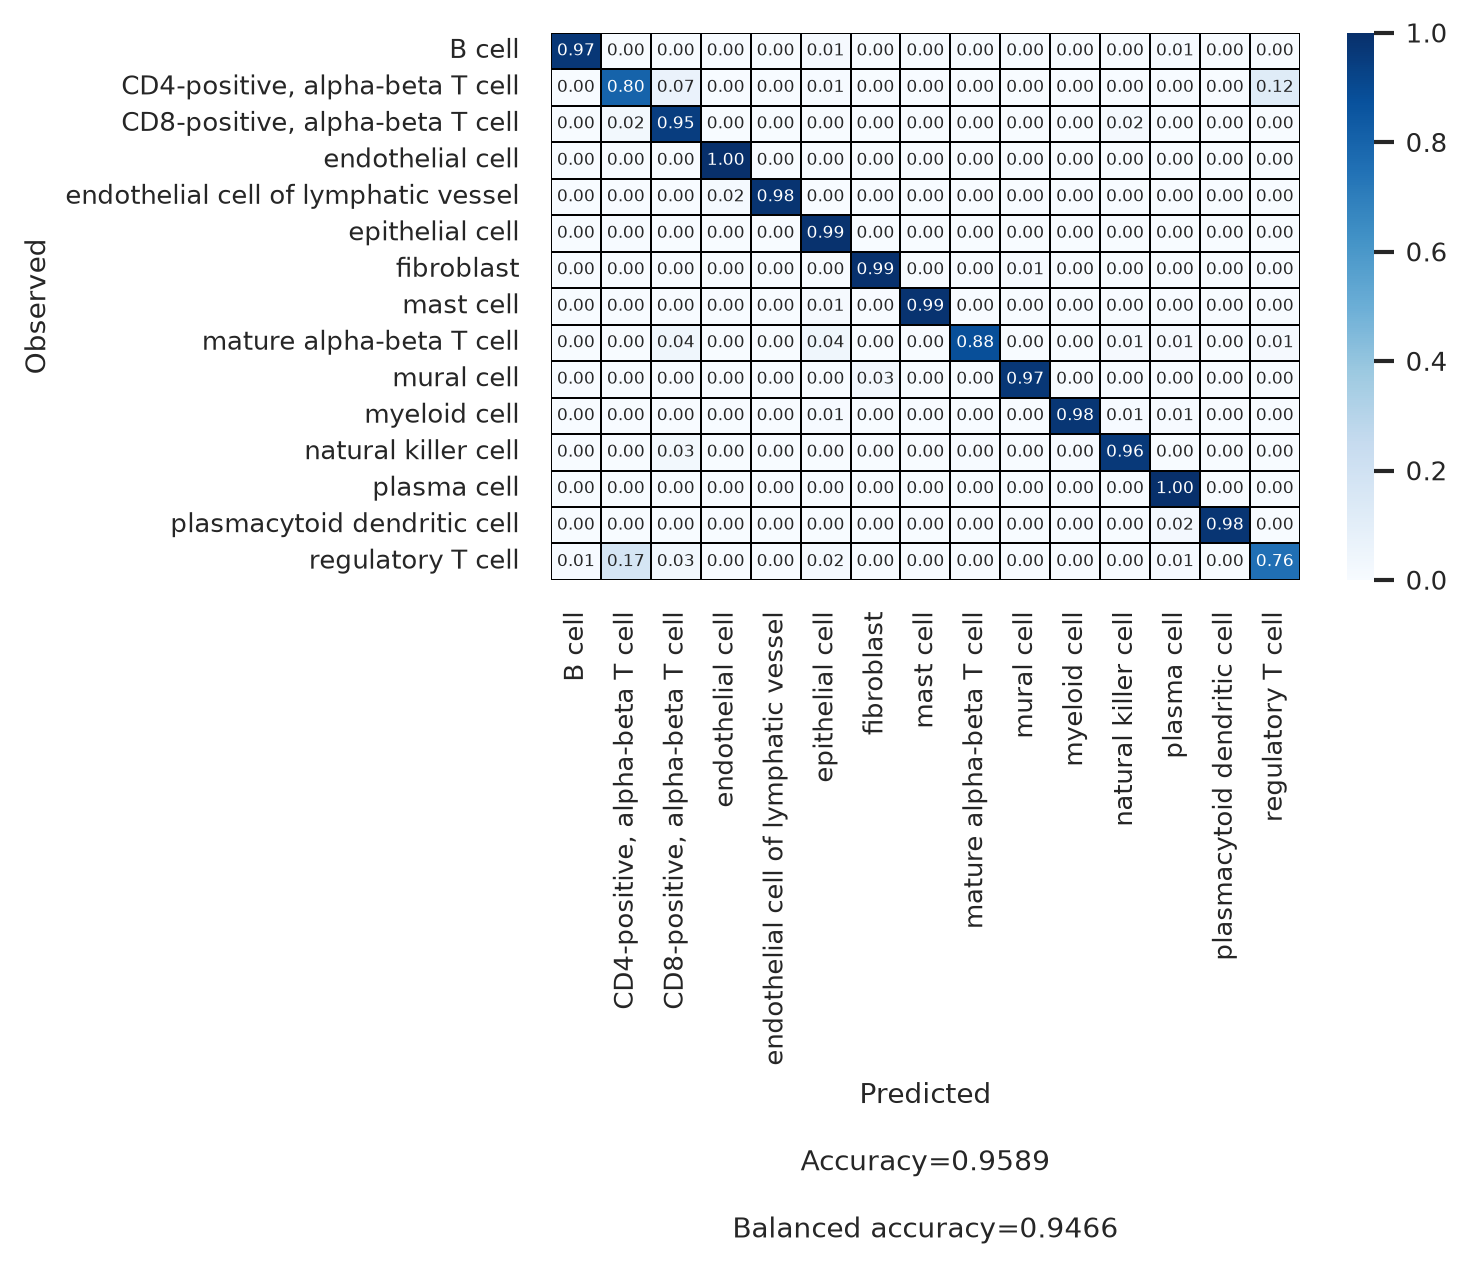

In [34]:
sns.set(font_scale = 0.7)
plt.figure(figsize = (5, 3))
scparadise.scnoah.conf_matrix(
    adata_test,
    celltype = 'celltype_l2',
    pred_celltype = 'pred_celltype_l2',
    annot_kws = {"size":5},
    linewidths = 0.1, linecolor = 'black',
    fmt =  ".2f",
    ndigits_metrics = 4,
    vmin = 0, vmax = 1
)

In [35]:
# Save anndata with predicted annotations
adata_test.write_h5ad('adata_test_imbalanced_model.h5ad')

In [36]:
import session_info2
session_info2.session_info()

Package,Version
pandas,2.3.3
scanpy,1.11.5
scparadise,1.2.0
seaborn,0.13.2
matplotlib,3.11.0
numpy,2.4.6
anndata,0.12.16
Component,Info
Python,"3.11.15 (main, Jun 11 2026, 15:20:16) [GCC 14.3.0]"
OS,Linux-6.8.0-138-generic-x86_64-with-glibc2.39
